In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
filePath = '/mnt/DataDrive3/emeyer/TreeShrewObjectRecognition/5_behaviorModeling/'
taskName = 'Camel_v2_test_nn' #'Camel_v2_test_nn' 'Camel_Rhino_test_nn' 'Camel_background_matrix'

df_pixel_orig = pd.read_csv(f'{filePath}distData/{taskName}/original_pixel_distances.csv', header=None)
df_pixelcenter_orig = pd.read_csv(f'{filePath}distData/{taskName}/register_centered_pixel_distances.csv', header=None)
df_pixelscale_orig = pd.read_csv(f'{filePath}distData/{taskName}/register_scaled_pixel_distances.csv', header=None)
df_pixelcenterscale_orig = pd.read_csv(f'{filePath}distData/{taskName}/register_centered_scaled_pixel_distances.csv', header=None)
df_binary_object = pd.read_csv(f'{filePath}distData/{taskName}/binary_object_distances_combmodel.csv', header=None)
df_binary_object_scaled = pd.read_csv(f'{filePath}distData/{taskName}/binary_object_scaled_distances_combmodel.csv', header=None)
df_gabor = pd.read_csv(f'{filePath}distData/{taskName}/gabor_distances_norm.csv', header=None)
df_isetbio_NN = pd.read_csv(f'{filePath}distData/{taskName}/isetbio_distances_combmodel.csv', header=None)
df_texture_inplace = pd.read_csv(f'{filePath}distData/{taskName}/texture_inplace_distances_combmodel.csv', header=None)
df_texture = pd.read_csv(f'{filePath}distData/{taskName}/texture_crop_distances_combmodel.csv', header=None)
df_skeleton = pd.read_csv(f'{filePath}distData/{taskName}/skeleton_distances_combmodel.csv', header=None)
df_skeleton_scaled = pd.read_csv(f'{filePath}distData/{taskName}/skeleton_scaled_distances_combmodel.csv', header=None)
df_salicon = pd.read_csv(f'{filePath}distData/{taskName}/salicon_distances_combmodel.csv', header=None)
df_behavior = pd.read_csv(f'{filePath}distData/{taskName}/treeshrew_behavior.csv', header=None)
df_alexnet_cont = pd.read_csv(f'{filePath}distData/{taskName}/alexnet_mouse_distances2.csv', header=None)
df_alexnet_sup = pd.read_csv(f'{filePath}distData/{taskName}/alexnet_distances2.csv', header=None)
df_vgg = pd.read_csv(f'{filePath}distData/{taskName}/vgg16_distances2.csv', header=None)
df_size_diff = pd.read_csv(f'{filePath}distData/{taskName}/size_differences.csv', header=None)
df_maxdim_diff = pd.read_csv(f'{filePath}distData/{taskName}/original_maxdim_differences.csv', header=None)
df_binsum_diff = pd.read_csv(f'{filePath}distData/{taskName}/original_binarysum_differences.csv', header=None)

# Combine the dataframes into a single dataframe
df_combined = pd.concat([df_behavior, df_size_diff, df_maxdim_diff, df_binsum_diff, df_pixel_orig, df_pixelcenter_orig, df_pixelscale_orig,df_pixelcenterscale_orig, df_binary_object, df_binary_object_scaled, df_gabor, df_texture, df_texture_inplace, df_skeleton, df_skeleton_scaled, df_salicon, df_alexnet_cont, df_alexnet_sup, df_vgg], axis=1, ignore_index=True)
df_labels = ['Behavior','Obj Size Diff', 'Obj Max Dim Diff','Obj Binary Pix Diff','Pixel', 'Pixel Centered','Pixel Scaled','Pixel Centered, Scaled','Binary Object','Binary Object Scaled', 'Gabor', 'Texture','Texture In-Place', 'Skeleton','Skeleton Scaled','Salicon', 'Cont. AlexNet', 'Sup. AlexNet', 'VGG16']

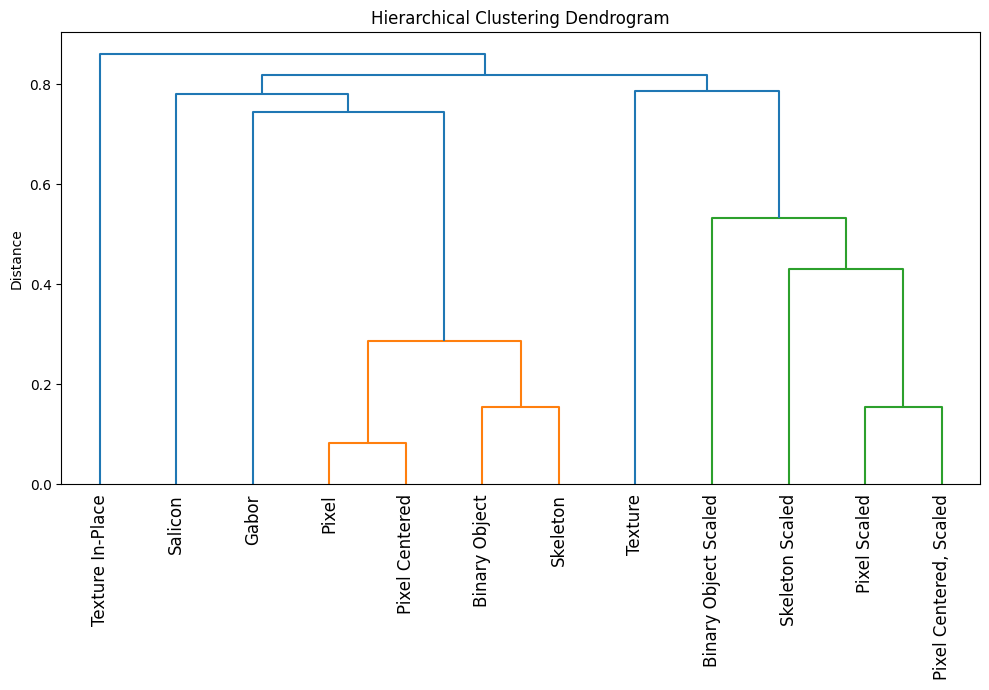

/tmp/ipykernel_2659315/1809558208.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


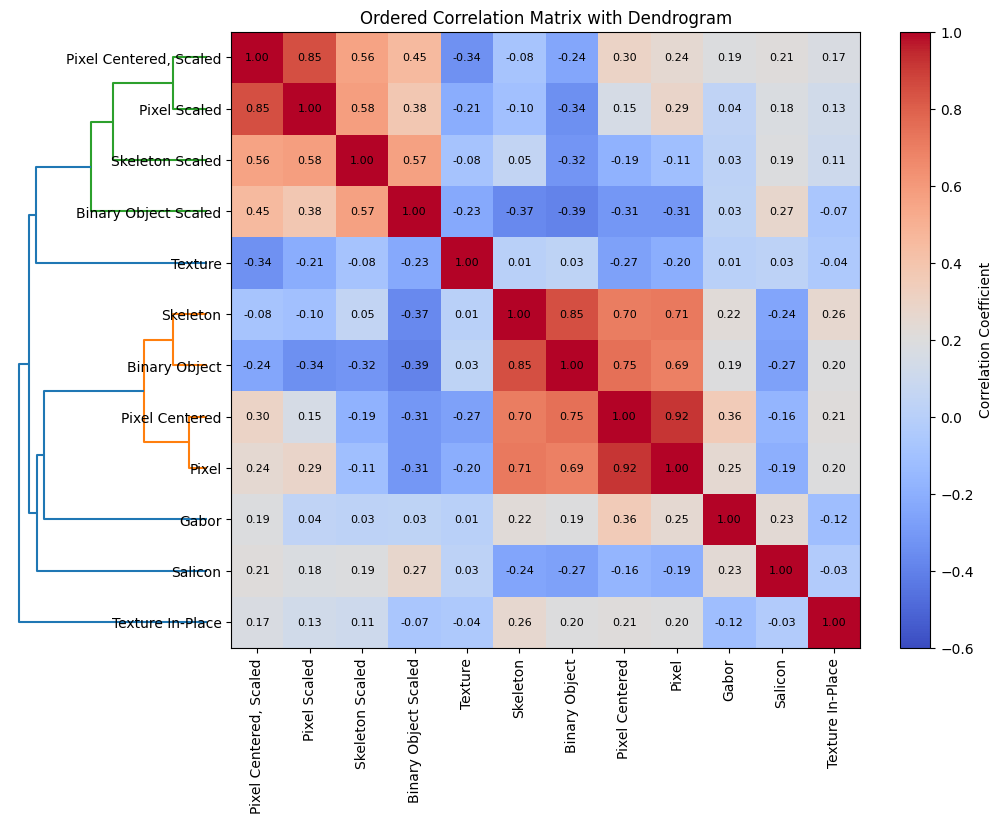

In [9]:
# Make correlation matrix with all columns of df_combined
correlation_matrix = df_combined.corr().iloc[4:-3, 4:-3] # Exclude the first column (behavior)
# Set the labels for the heatmap
df_labels_red = df_labels[4:-3]  # Exclude behavior and last three models for labeling

# Perform hierarchical clustering on the correlation matrix
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram

# Convert the correlation matrix to a distance matrix
distance_matrix = 1 - correlation_matrix.abs()
# Perform hierarchical clustering
linked = sch.linkage(squareform(distance_matrix), method='average')
# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(linked, labels=df_labels_red, orientation='top', leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig(f'{filePath}figures/{taskName}_ordered_dendrogram.png', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_ordered_dendrogram.svg', dpi=300)
plt.show()

# Order the correlation matrix based on the clustering
ordered_indices = np.flip(dendrogram['leaves'])
ordered_correlation_matrix = correlation_matrix.iloc[ordered_indices, ordered_indices]
ordered_labels = [df_labels_red[i] for i in ordered_indices]

# Plot the ordered heatmap
import matplotlib.gridspec as gridspec

# Create figure with GridSpec for layout
fig = plt.figure(figsize=(13, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 4], wspace=0.05)

# Plot dendrogram on the left
ax_dendro = fig.add_subplot(gs[0])
dendrogram_left = sch.dendrogram(linked, labels=df_labels_red, orientation='left', no_labels=True)
ax_dendro.set_xticks([])
ax_dendro.set_yticks([])
ax_dendro.spines['top'].set_visible(False)
ax_dendro.spines['right'].set_visible(False)
ax_dendro.spines['bottom'].set_visible(False)
ax_dendro.spines['left'].set_visible(False)

# Plot heatmap on the right
ax_heatmap = fig.add_subplot(gs[1])
im = ax_heatmap.imshow(ordered_correlation_matrix, cmap='coolwarm', interpolation='nearest', vmin=-0.6, vmax=1, aspect='auto')
for (i, j), value in np.ndenumerate(ordered_correlation_matrix):
    ax_heatmap.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=8)
ax_heatmap.set_xticks(range(len(ordered_correlation_matrix.columns)))
ax_heatmap.set_xticklabels(ordered_labels, rotation=90)
ax_heatmap.set_yticks(range(len(ordered_correlation_matrix.columns)))
ax_heatmap.set_yticklabels(ordered_labels)
ax_heatmap.set_title('Ordered Correlation Matrix with Dendrogram')

# Add colorbar
cbar = plt.colorbar(im, ax=ax_heatmap, label='Correlation Coefficient')

plt.tight_layout()
plt.savefig(f'{filePath}figures/{taskName}_ordered_correlation_matrix_dendrogram.png', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_ordered_correlation_matrix_dendrogram.svg', dpi=300)
plt.show()

Pixel Centered, Scaled: Correlation = -0.160, 95% CI = [-0.315, -0.012]
Pixel Scaled: Correlation = -0.258, 95% CI = [-0.429, -0.078]
Skeleton Scaled: Correlation = -0.007, 95% CI = [-0.221, 0.169]
Binary Object Scaled: Correlation = -0.123, 95% CI = [-0.303, 0.075]
Texture: Correlation = 0.011, 95% CI = [-0.221, 0.182]
Skeleton: Correlation = 0.263, 95% CI = [0.155, 0.385]
Binary Object: Correlation = 0.348, 95% CI = [0.191, 0.516]
Pixel Centered: Correlation = 0.177, 95% CI = [-0.019, 0.418]
Pixel: Correlation = 0.104, 95% CI = [-0.090, 0.362]
Gabor: Correlation = -0.001, 95% CI = [-0.171, 0.168]
Salicon: Correlation = -0.139, 95% CI = [-0.315, 0.045]
Texture In-Place: Correlation = 0.188, 95% CI = [-0.018, 0.388]


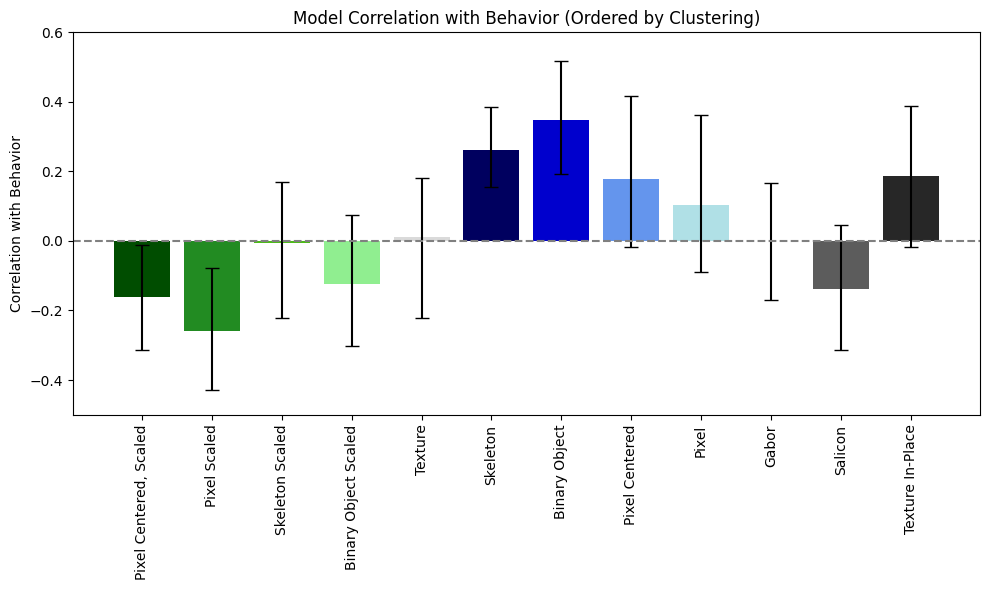

In [10]:
colors = ['#004d00', '#228B22', '#4CBB17', '#90EE90',  # Greens (darker to lighter)
          "#DADADA",
          '#00005f', '#0000CD', '#6495ED', '#B0E0E6',  # Blues (darker to lighter)
          "#969696", "#5C5C5C", "#272727"]  # Reds (darker to lighter)

# Compute correlations of each model used in clustering with behavior in order of clustering
behavior_correlations = []
for i in ordered_indices:
    corr = df_combined.iloc[:, 0].corr(df_combined.iloc[:, i + 4])  # +4 to account for behavior and size diff columns
    behavior_correlations.append(corr)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(behavior_correlations)), behavior_correlations, color=colors)
# Compute confidence intervals using bootstrap
n_bootstraps = 1000
bootstrap_cis = []
for idx, i in enumerate(ordered_indices):
    data_x = df_combined.iloc[:, 0].values
    data_y = df_combined.iloc[:, i + 4].values
    bootstrapped_corrs = []
    for _ in range(n_bootstraps):
        indices = np.random.choice(range(len(data_x)), size=len(data_x), replace=True)
        boot_x = data_x[indices]
        boot_y = data_y[indices]
        boot_corr = np.corrcoef(boot_x, boot_y)[0, 1]
        bootstrapped_corrs.append(boot_corr)
    lower_ci = np.percentile(bootstrapped_corrs, 2.5)
    upper_ci = np.percentile(bootstrapped_corrs, 97.5)
    bootstrap_cis.append((lower_ci, upper_ci))
    print(f'{df_labels_red[i]}: Correlation = {behavior_correlations[idx]:.3f}, 95% CI = [{lower_ci:.3f}, {upper_ci:.3f}]')

# Add error bars to the bars
for i, bar in enumerate(bars):
    lower_ci, upper_ci = bootstrap_cis[i]
    plt.errorbar(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 yerr=[[bar.get_height() - lower_ci], [upper_ci - bar.get_height()]],
                 fmt='none', ecolor='black', capsize=5)

plt.xticks(range(len(behavior_correlations)), ordered_labels, rotation=90)
plt.ylabel('Correlation with Behavior')
plt.title('Model Correlation with Behavior (Ordered by Clustering)')
plt.ylim(-0.5, 0.6)
plt.axhline(y=0, color='gray', linestyle='--')
plt.tight_layout()
plt.savefig(f'{filePath}figures/{taskName}_model_behavior_correlation_ordered.png', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_model_behavior_correlation_ordered.svg', dpi=300)
plt.show()

In [11]:
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

def partial_correlation(x, y, control):
    """
    Compute partial correlation between x and y controlling for control variable
    
    Parameters:
    x: variable 1 (flattened)
    y: variable 2 (flattened) 
    control: control variable - size differences (flattened)
    """
    # Regress control out of x
    model_x = LinearRegression()
    model_x.fit(control.reshape(-1, 1), x.reshape(-1, 1))
    x_resid = x - model_x.predict(control.reshape(-1, 1)).flatten()
    
    # Regress control out of y
    model_y = LinearRegression()
    model_y.fit(control.reshape(-1, 1), y.reshape(-1, 1))
    y_resid = y - model_y.predict(control.reshape(-1, 1)).flatten()
    
    # Correlate the residuals
    corr, pval = pearsonr(x_resid, y_resid)
    return corr, pval

Cont. AlexNet: Correlation = 0.276, 95% CI = [0.144, 0.429]
Cont. AlexNet (Size Regressed): Correlation = 0.215, 95% CI = [0.057, 0.401]
Sup. AlexNet: Correlation = 0.197, 95% CI = [-0.012, 0.387]
Sup. AlexNet (Size Regressed): Correlation = -0.025, 95% CI = [-0.249, 0.160]
VGG16: Correlation = 0.264, 95% CI = [0.121, 0.416]
VGG16 (Size Regressed): Correlation = -0.022, 95% CI = [-0.203, 0.129]


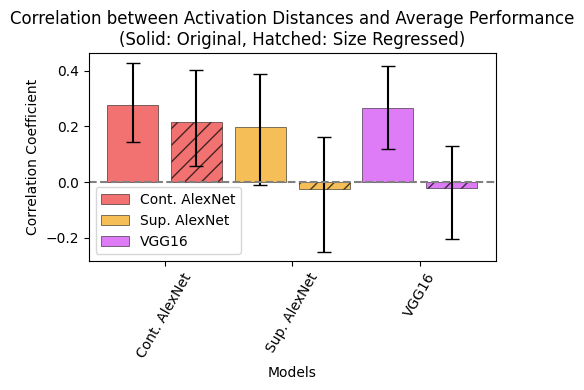

In [15]:
# colors are three shades of purple
colors_NN = ["#ed3636","#f1a310","#d043f3"]
# Plot bar graph for each data set's correlation with behavior
df_combined_NN = pd.concat([df_behavior, df_alexnet_cont, df_alexnet_sup, df_vgg], axis=1, ignore_index=True)
df_labels_NN = ['Behavior', 'Cont. AlexNet', 'Sup. AlexNet', 'VGG16']

plt.figure(figsize=(5, 4))
for i in range(len(df_labels_NN[1:])):
    # Calculate the original correlation coefficient
    correlation = df_combined_NN.corr().iloc[0, i+1]

    # Calculate the confidence interval with bootstrapping
    n_bootstraps = 1000
    bootstrapped_correlations = []
    for _ in range(n_bootstraps):
        # Resample the data with replacement
        resampled_data = df_combined_NN.sample(frac=1, replace=True)
        # Calculate the correlation coefficient for the resampled data
        bootstrapped_correlation = resampled_data.corr().iloc[0, i+1]
        bootstrapped_correlations.append(bootstrapped_correlation)

    # Calculate the confidence interval
    ci_lower = np.percentile(bootstrapped_correlations, 2.5)
    ci_upper = np.percentile(bootstrapped_correlations, 97.5)
    print(f'{df_labels_NN[i+1]}: Correlation = {correlation:.3f}, 95% CI = [{ci_lower:.3f}, {ci_upper:.3f}]')

    # Compute partial correlation controlling for size differences
    X = df_combined_NN.iloc[:, 0].values
    y = df_combined_NN.iloc[:, i+1].values
    sizediff = df_size_diff.values.flatten()
    correlation_regressed, pval = partial_correlation(X, y, sizediff)


    # model_lr = LinearRegression()
    # X = df_size_diff.values.reshape(-1, 1)
    # y = df_combined_NN.iloc[:, i+1].values
    # model_lr.fit(X, y)
    # y_pred = model_lr.predict(X)
    # residuals = y - y_pred

    # # Calculate correlation after regressing out size diff
    # correlation_regressed = np.corrcoef(df_combined_NN.iloc[:, 0], residuals)[0, 1]

    # Bootstrap confidence interval for regressed correlation
    bootstrapped_correlations_regressed = []
    for _ in range(n_bootstraps):
        indices = np.random.choice(len(X), len(X), replace=True)
        partial_corr, pval = partial_correlation(X[indices], y[indices], sizediff[indices])
        # bootstrapped_correlation_regressed = np.corrcoef(df_combined_NN.iloc[indices, 0], residuals[indices])[0, 1]
        bootstrapped_correlations_regressed.append(partial_corr)

    ci_lower_regressed = np.percentile(bootstrapped_correlations_regressed, 2.5)
    ci_upper_regressed = np.percentile(bootstrapped_correlations_regressed, 97.5)
    print(f'{df_labels_NN[i+1]} (Size Regressed): Correlation = {correlation_regressed:.3f}, 95% CI = [{ci_lower_regressed:.3f}, {ci_upper_regressed:.3f}]')

    # Plot original correlation
    plt.bar(i*2, correlation, label=df_labels_NN[i+1], alpha=0.7, color=colors_NN[i], edgecolor='black', linewidth=0.5)
    plt.errorbar(i*2, correlation, yerr=[[correlation - ci_lower], [ci_upper - correlation]], fmt='', color='black', capsize=5)
    
    # Plot regressed correlation
    plt.bar(i*2+1, correlation_regressed, alpha=0.7, color=colors_NN[i], edgecolor='black', linewidth=0.5, hatch='//')
    plt.errorbar(i*2+1, correlation_regressed, yerr=[[correlation_regressed - ci_lower_regressed], [ci_upper_regressed - correlation_regressed]], fmt='', color='black', capsize=5)

plt.axhline(y=0, color='gray', linestyle='--')
x_positions = [i*2 + 0.5 for i in range(len(df_labels_NN[1:]))]
plt.xticks(x_positions, df_labels_NN[1:], rotation=60)
plt.title('Correlation between Activation Distances and Average Performance\n(Solid: Original, Hatched: Size Regressed)')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Models')
plt.legend()
plt.tight_layout()
plt.savefig(f'{filePath}figures/{taskName}_bar_correlation_NN.png', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_bar_correlation_NN.svg', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_bar_correlation_NN.pdf', dpi=300)
plt.show()

In [13]:
# Check how much size predicts each variable
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("=== Diagnostics ===")
for i in range(len(df_labels_NN)):
    X = df_size_diff.values.reshape(-1, 1)
    y = df_combined_NN.iloc[:, i].values
    
    model = LinearRegression()
    model.fit(X, y)
    r2 = r2_score(y, model.predict(X))
    
    print(f"{df_labels_NN[i]}: R² with size = {r2:.4f}")
    print(f"  Correlation with size: {np.corrcoef(X.flatten(), y)[0,1]:.4f}")

# Also check correlation between behavior and neural distances BEFORE and AFTER
print("\n=== Correlation Comparison ===")
for i in range(len(df_labels_NN[1:])):
    X = df_combined_NN.iloc[:, 0].values  # Behavior
    y = df_combined_NN.iloc[:, i+1].values  # Neural
    sizediff = df_size_diff.values.flatten()
    
    # Original correlation
    orig_corr = np.corrcoef(X, y)[0, 1]
    
    # Partial correlation
    partial_corr, pval = partial_correlation(X, y, sizediff)
    
    print(f"{df_labels_NN[i+1]}:")
    print(f"  Original: {orig_corr:.4f}")
    print(f"  Partial:  {partial_corr:.4f}")
    print(f"  Difference: {abs(orig_corr - partial_corr):.4f}")

=== Diagnostics ===
Behavior: R² with size = 0.1508
  Correlation with size: 0.3883
Cont. AlexNet: R² with size = 0.0443
  Correlation with size: 0.2105
Sup. AlexNet: R² with size = 0.3107
  Correlation with size: 0.5574
VGG16: R² with size = 0.5125
  Correlation with size: 0.7159

=== Correlation Comparison ===
Cont. AlexNet:
  Original: 0.2758
  Partial:  0.2154
  Difference: 0.0604
Sup. AlexNet:
  Original: 0.1973
  Partial:  -0.0250
  Difference: 0.2223
VGG16:
  Original: 0.2640
  Partial:  -0.0217
  Difference: 0.2857


Obj Size Diff: Correlation = 0.388, 95% CI = [0.227, 0.580]
Obj Max Dim Diff: Correlation = 0.256, 95% CI = [0.085, 0.448]
Obj Binary Pix Diff: Correlation = 0.320, 95% CI = [0.161, 0.485]
Pixel: Correlation = 0.104, 95% CI = [-0.092, 0.348]
Pixel Centered: Correlation = 0.177, 95% CI = [-0.018, 0.410]
Pixel Scaled: Correlation = -0.258, 95% CI = [-0.410, -0.088]
Pixel Centered, Scaled: Correlation = -0.160, 95% CI = [-0.300, -0.011]
Binary Object: Correlation = 0.348, 95% CI = [0.212, 0.523]
Binary Object Scaled: Correlation = -0.123, 95% CI = [-0.304, 0.040]
Gabor: Correlation = -0.001, 95% CI = [-0.182, 0.166]
Texture: Correlation = 0.011, 95% CI = [-0.212, 0.195]
Texture In-Place: Correlation = 0.188, 95% CI = [-0.003, 0.384]
Skeleton: Correlation = 0.263, 95% CI = [0.149, 0.402]
Skeleton Scaled: Correlation = -0.007, 95% CI = [-0.229, 0.173]
Salicon: Correlation = -0.139, 95% CI = [-0.310, 0.038]
Cont. AlexNet: Correlation = 0.276, 95% CI = [0.144, 0.443]
Sup. AlexNet: Correlation

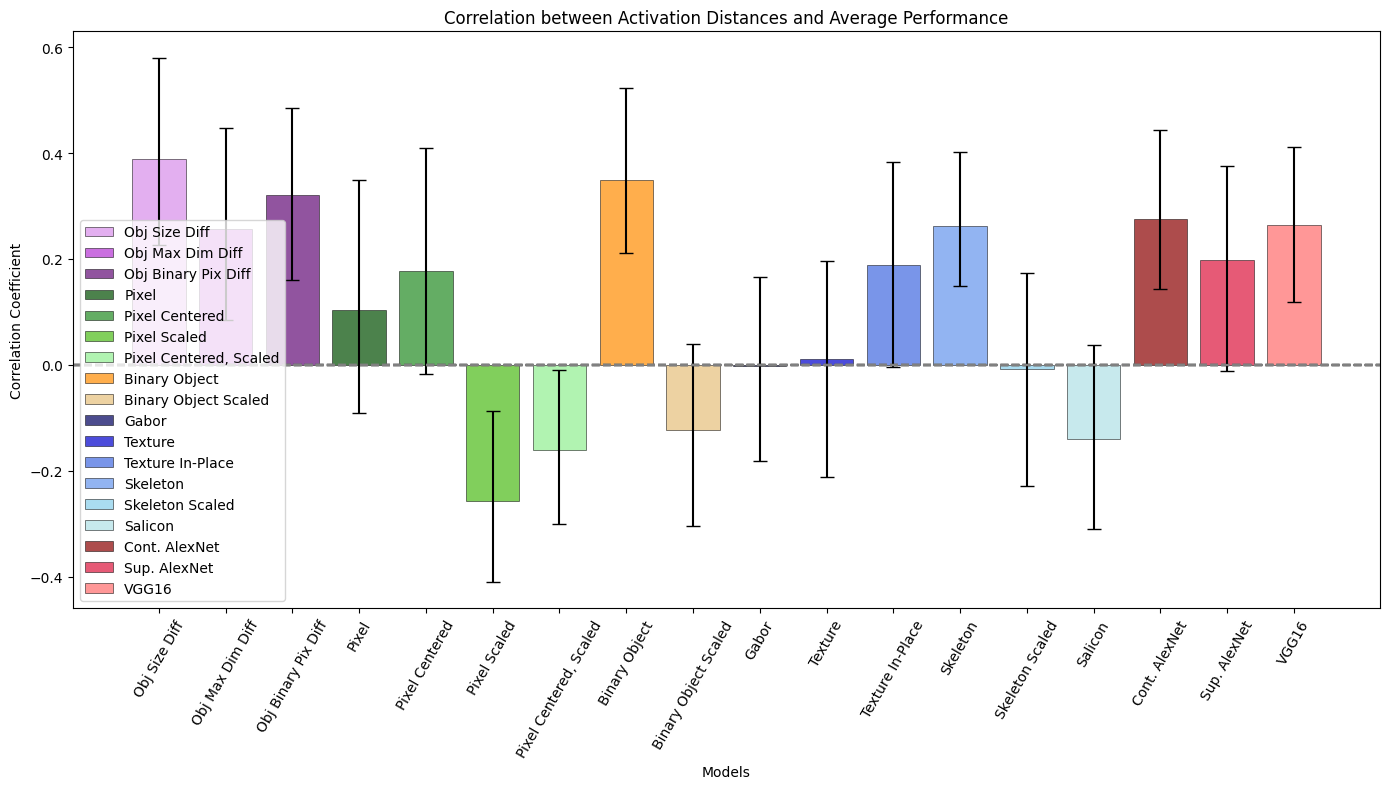

In [43]:
# Set colors for each model where first four are shades of green, next five are shades of blue, and last three are shades of red
colors = ["#d88eeb","#b432d4","#620b77",
          '#004d00', '#228B22', '#4CBB17', '#90EE90',  # Greens (darker to lighter)
          '#FF8C00', "#E6C07B",
          '#00005f', '#0000CD', '#4169E1', '#6495ED', '#87CEEB', '#B0E0E6',  # Blues (darker to lighter)
          '#8B0000', '#DC143C', '#FF6B6B']  # Reds (darker to lighter)

# Plot bar graph for each data set's correlation with behavior
plt.figure(figsize=(14, 8))
for i in range(len(df_labels)-1):
    # Calculate the correlation coefficient
    correlation = df_combined.corr().iloc[0, i+1]

    # Calculate the confidence interval with bootstrapping
    n_bootstraps = 1000
    bootstrapped_correlations = []
    for _ in range(n_bootstraps):
        # Resample the data with replacement
        resampled_data = df_combined.sample(frac=1, replace=True)
        # Calculate the correlation coefficient for the resampled data
        bootstrapped_correlation = resampled_data.corr().iloc[0, i+1]
        bootstrapped_correlations.append(bootstrapped_correlation)

    # Calculate the confidence interval
    ci_lower = np.percentile(bootstrapped_correlations, 2.5)
    ci_upper = np.percentile(bootstrapped_correlations, 97.5)
    print(f'{df_labels[i+1]}: Correlation = {correlation:.3f}, 95% CI = [{ci_lower:.3f}, {ci_upper:.3f}]')

    # Plot bar graph for ech data set's correlation with behavior
    plt.bar(i, correlation, label=df_labels[i+1], alpha=0.7, color=colors[i], edgecolor='black', linewidth=0.5)
    plt.errorbar(i, correlation, yerr=[[correlation - ci_lower], [ci_upper - correlation]], fmt='', color='black', capsize=5)
    plt.xticks(range(len(df_labels)-1), df_labels[1:], rotation=60)
    plt.axhline(y=0, color='gray', linestyle='--')
    plt.title('Correlation between Activation Distances and Average Performance')
    plt.ylabel('Correlation Coefficient')
    plt.xlabel('Models')
    plt.legend()
    plt.tight_layout()

plt.savefig(f'{filePath}figures/{taskName}_bar_correlation.png', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_bar_correlation.svg', dpi=300)
plt.show()


Obj Max Dim Diff: Correlation = 0.064, 95% CI = [-0.111, 0.261]
Obj Binary Pix Diff: Correlation = 0.055, 95% CI = [-0.104, 0.231]
Pixel: Correlation = -0.215, 95% CI = [-0.400, 0.014]
Pixel Centered: Correlation = -0.149, 95% CI = [-0.326, 0.084]
Pixel Scaled: Correlation = -0.253, 95% CI = [-0.398, -0.076]
Pixel Centered, Scaled: Correlation = -0.198, 95% CI = [-0.344, -0.061]
Binary Object: Correlation = 0.112, 95% CI = [-0.015, 0.277]
Binary Object Scaled: Correlation = -0.077, 95% CI = [-0.257, 0.115]
Gabor: Correlation = -0.029, 95% CI = [-0.195, 0.138]
Texture: Correlation = 0.125, 95% CI = [-0.067, 0.291]
Texture In-Place: Correlation = 0.084, 95% CI = [-0.122, 0.280]
Skeleton: Correlation = 0.025, 95% CI = [-0.125, 0.170]
Skeleton Scaled: Correlation = 0.029, 95% CI = [-0.180, 0.202]
Salicon: Correlation = -0.049, 95% CI = [-0.237, 0.165]
Cont. AlexNet: Correlation = 0.198, 95% CI = [0.045, 0.347]
Sup. AlexNet: Correlation = -0.023, 95% CI = [-0.206, 0.175]
VGG16: Correlation 

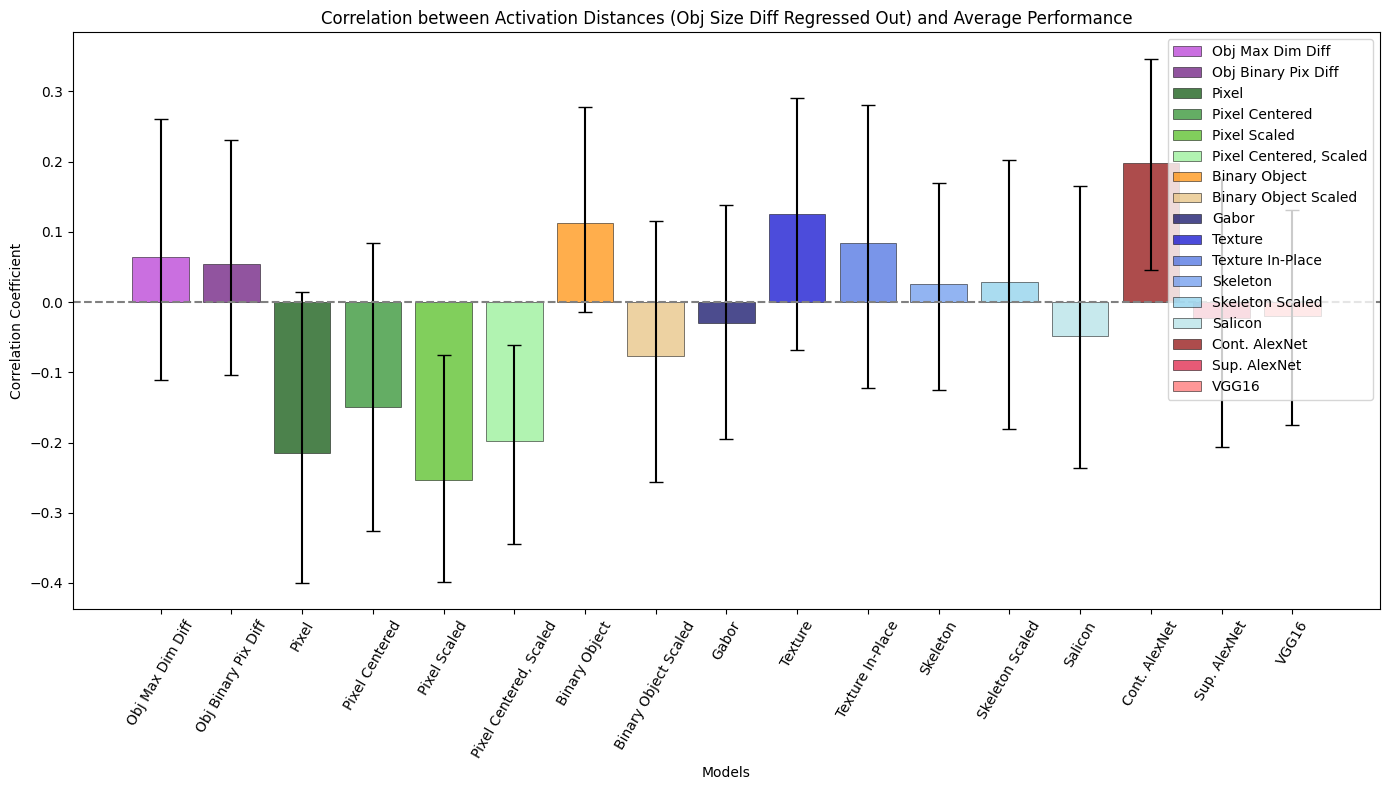

In [45]:
# Create new correlation bar graph that regresses out obj size difference from each model distance metric before calculating correlation with behavior
from sklearn.linear_model import LinearRegression
plt.figure(figsize=(14, 8))
for i in range(1, len(df_labels)-1):  # Start from 1 to exclude obj size diff
    # Regress out obj size difference from each model distance metric
    model = LinearRegression()
    X = df_size_diff.values.reshape(-1, 1)
    y = df_combined.iloc[:, i+1].values
    model.fit(X, y)
    y_pred = model.predict(X)
    residuals = y - y_pred

    # Calculate the correlation coefficient between residuals and behavior
    correlation = np.corrcoef(df_combined.iloc[:, 0], residuals)[0, 1]

    # Calculate the confidence interval with bootstrapping
    n_bootstraps = 1000
    bootstrapped_correlations = []
    for _ in range(n_bootstraps):
        # Resample the residuals and behavior with replacement
        indices = np.random.choice(len(residuals), len(residuals), replace=True)
        
        # Calculate correlation for bootstrapped residuals
        bootstrapped_correlation = np.corrcoef(df_combined.iloc[indices, 0], residuals[indices])[0, 1]
        bootstrapped_correlations.append(bootstrapped_correlation)

    # Calculate the confidence interval
    ci_lower = np.percentile(bootstrapped_correlations, 2.5)
    ci_upper = np.percentile(bootstrapped_correlations, 97.5)
    print(f'{df_labels[i+1]}: Correlation = {correlation:.3f}, 95% CI = [{ci_lower:.3f}, {ci_upper:.3f}]')

    # Plot bar graph for each data set's correlation with behavior after regressing out obj size difference
    plt.bar(i-1, correlation, label=df_labels[i+1], alpha=0.7, color=colors[i], edgecolor='black', linewidth=0.5)
    plt.errorbar(i-1, correlation, yerr=[[correlation - ci_lower], [ci_upper - correlation]], fmt='', color='black', capsize=5)

plt.xticks(range(len(df_labels)-2), df_labels[2:], rotation=60)
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Correlation between Activation Distances (Obj Size Diff Regressed Out) and Average Performance')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Models')
plt.legend()
plt.tight_layout()
plt.savefig(f'{filePath}figures/{taskName}_bar_correlation_size_regressed.png', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_bar_correlation_size_regressed.svg', dpi=300)
plt.show()

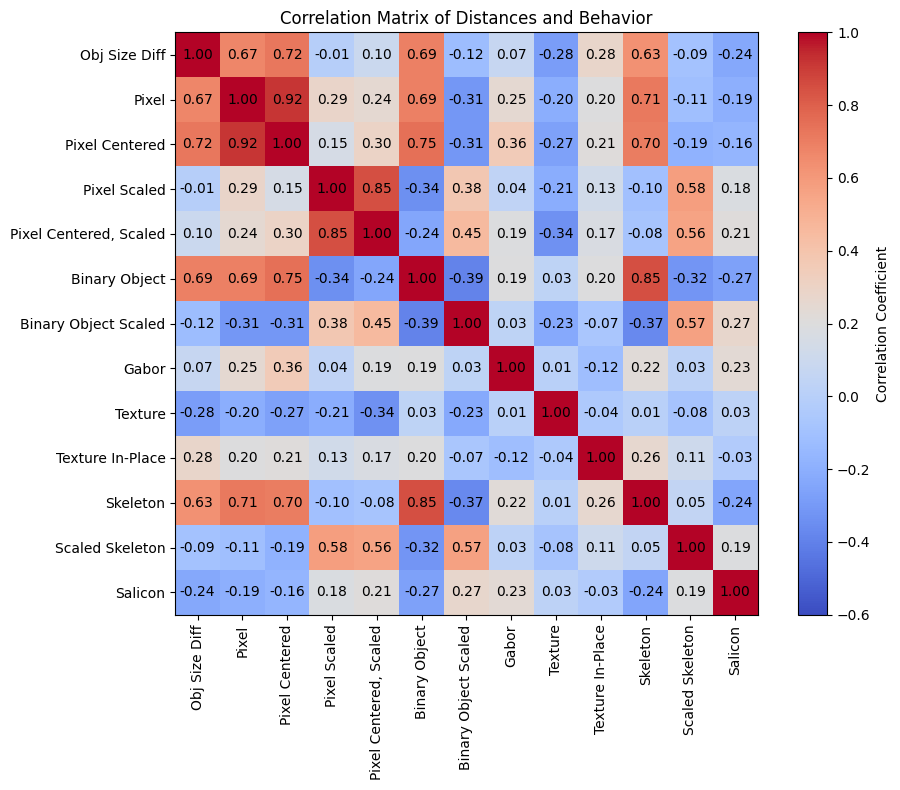

In [8]:
# Make correlation matrix with all columns of df_combined
correlation_matrix = df_combined.corr().iloc[1:-3, 1:-3]  # Exclude the first column (behavior)
# Set the labels for the heatmap
df_labels_red = df_labels[1:-3]
# df_labels = ['Pixel', 'Pixel Centered','Pixel Scaled','Pixel Centered, Scaled', 'Gabor', 'Texture','Salicon', 'Skeleton', 'VGG16', 'Cont. AlexNet', 'Sup. AlexNet']
# Set the figure size
plt.figure(figsize=(10, 8))
# Create a heatmap using the correlation matrix
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest', vmin=-0.6, vmax=1)
# Display the correlation values on the heatmap
for (i, j), value in np.ndenumerate(correlation_matrix):
    plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')
plt.colorbar(label='Correlation Coefficient')
plt.title('Correlation Matrix of Distances and Behavior')
plt.xticks(range(len(correlation_matrix.columns)), df_labels_red, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), df_labels_red)
plt.tight_layout()
plt.savefig(f'{filePath}figures/{taskName}_correlation_matrix.svg', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_correlation_matrix.png', dpi=300)
plt.show()

/home/arcarolab_adm/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


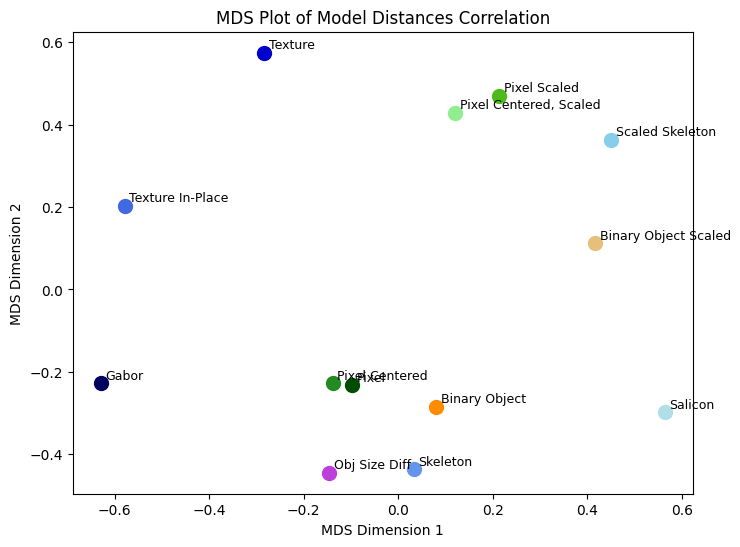

In [10]:
# Perform MDS on the correlation matrix and color each point based on model type
from sklearn.manifold import MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
dissimilarity = 1 - correlation_matrix.abs()
mds_coords = mds.fit_transform(dissimilarity)
plt.figure(figsize=(8, 6))
for i, label in enumerate(df_labels_red):
    plt.scatter(mds_coords[i, 0], mds_coords[i, 1], label=label, color=colors[i], s=100)
    plt.text(mds_coords[i, 0]+0.01, mds_coords[i, 1]+0.01, label, fontsize=9)
plt.title('MDS Plot of Model Distances Correlation')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.savefig(f'{filePath}figures/{taskName}_correlation_matrix_MDS.png', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_correlation_matrix_MDS.svg', dpi=300)
plt.show()

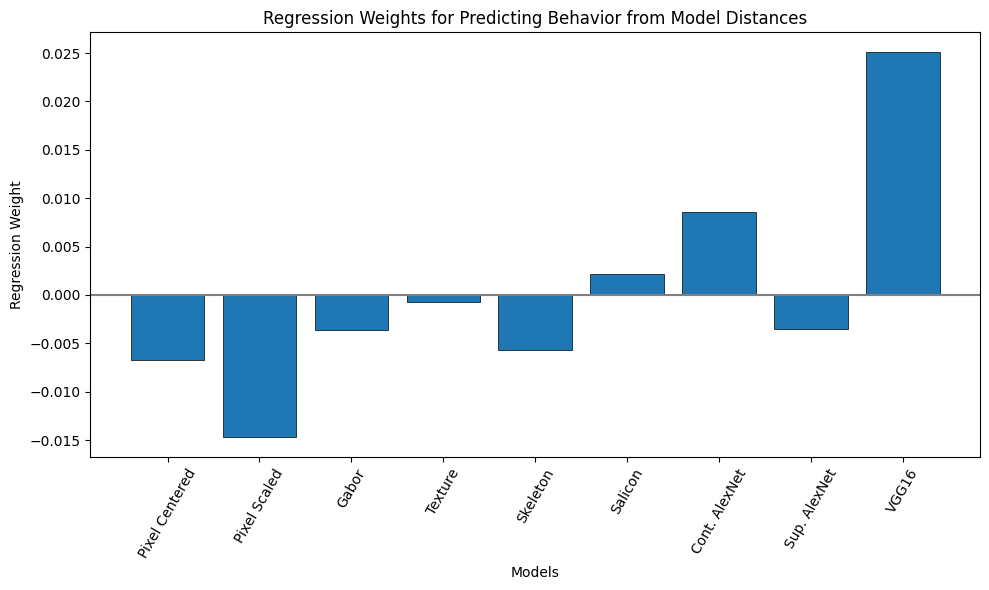

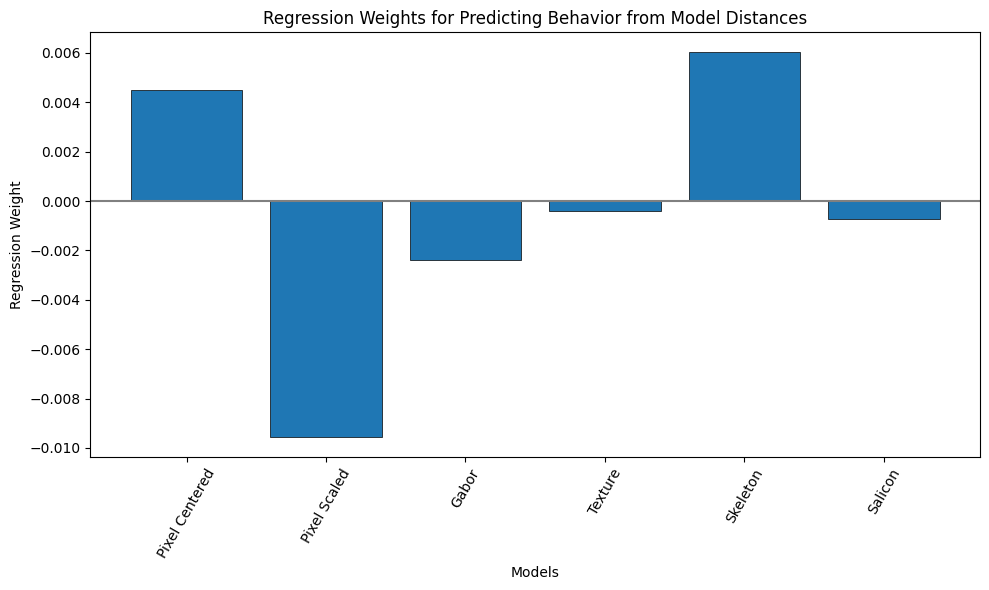

In [11]:
df_combined = pd.concat([df_pixelcenter_orig, df_pixelscale_orig, df_gabor, df_texture, df_skeleton, df_salicon, df_alexnet_cont, df_alexnet_sup, df_vgg], axis=1, ignore_index=True)
df_labels = ['Pixel Centered','Pixel Scaled', 'Gabor', 'Texture', 'Skeleton', 'Salicon', 'Cont. AlexNet', 'Sup. AlexNet', 'VGG16']

# Build regression model to predict behavior from all model distances
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X = df_combined.values
# zscore each model in X
X_z = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
y = df_behavior.values.ravel()

model = LinearRegression()
model.fit(X_z, y)
weights = model.coef_

plt.figure(figsize=(10, 6))
plt.bar(range(len(df_labels)), weights, edgecolor='black', linewidth=0.5)
plt.axhline(y=0, color='gray')
plt.xticks(range(len(df_labels)), df_labels, rotation=60)
plt.title('Regression Weights for Predicting Behavior from Model Distances')
plt.ylabel('Regression Weight')
plt.xlabel('Models')
plt.tight_layout()
# plt.savefig(f'{filePath}figures/{taskName}_regression_weights.png', dpi=300)
# plt.savefig(f'{filePath}figures/{taskName}_regression_weights.svg', dpi=300)
plt.show()

df_combined = pd.concat([df_pixelcenter_orig, df_pixelscale_orig, df_gabor, df_texture, df_skeleton, df_salicon], axis=1, ignore_index=True)
df_labels = ['Pixel Centered','Pixel Scaled', 'Gabor', 'Texture', 'Skeleton', 'Salicon']

# Build regression model to predict behavior from all model distances
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X = df_combined.values
X_z = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
y = df_behavior.values.ravel()

model = LinearRegression()
model.fit(X_z, y)
weights = model.coef_

plt.figure(figsize=(10, 6))
plt.bar(range(len(df_labels)), weights, edgecolor='black', linewidth=0.5)
plt.axhline(y=0, color='gray')
plt.xticks(range(len(df_labels)), df_labels, rotation=60)
plt.title('Regression Weights for Predicting Behavior from Model Distances')
plt.ylabel('Regression Weight')
plt.xlabel('Models')
plt.tight_layout()
# plt.savefig(f'{filePath}figures/{taskName}_regression_weights.png', dpi=300)
# plt.savefig(f'{filePath}figures/{taskName}_regression_weights.svg', dpi=300)
plt.show()